In [1]:
import os
from dotenv import load_dotenv  # iT is the package that we use to load our all the environment variables from the .env file

load_dotenv()  # Load environment variables from .env file

True

In [2]:
if os.environ["OPENAI_API_KEY"]:
    print("OPENAI_API_KEY is set.")
else:
    raise ValueError("OPENAI_API_KEY is not set. Please set it in the .env file.")

OPENAI_API_KEY is set.


Now we need to import some more packages. Langchain

In [3]:
from langchain_openai import ChatOpenAI

In [4]:
llm = ChatOpenAI(model="gpt-5-nano", temperature=0)

In [6]:
llm.invoke("Who is the prime minister of India?").content

'As of June 2024, Narendra Modi is the Prime Minister of India. He has held the office since May 2014 and was re-elected in 2019, leading the Bharatiya Janata Party (BJP) and the NDA. If you want the most current status beyond June 2024, I can check the latest sources.'

## **RAG IMPLEMENTATION WITH YOUR OWN TEXT DATA**

#### **STEP 1: Preparing Document for your Text**

In [8]:
from langchain_core.documents import Document

#Your text data
my_text = """Rohit Gurunath Sharma (born 30 April 1987) is an Indian international cricketer and the former captain of the India national cricket team in all formats of the game.[3] He is a right-handed top-order batter. He represents Mumbai in domestic cricket and Mumbai Indians in the Indian Premier League. Sharma was a member of the teams that won the 2007 T20 World Cup, the 2013 ICC Champions Trophy and was the winning captain of the 2024 T20 World Cup and the 2025 ICC Champions Trophy.

Sharma holds several batting records which include most runs in T20 Internationals, most sixes in international cricket,[a] most double centuries in ODI cricket (3), most centuries at Cricket World Cups (7) and joint most hundreds in Twenty20 Internationals (5).[5] He also holds the world record for the highest individual score (264) in a One Day International (ODI) and also holds the record for scoring most hundreds (five) in a single Cricket World Cup, for which he won the ICC Men's ODI Cricketer of the Year award in 2019.[6] He is the first and only captain to lead a team in all[b] ICC tournament finals.[7]

He formerly captained Mumbai Indians and the team has won five Indian Premier League titles in 2013, 2015, 2017, 2019 and 2020 under him, making him the most successful captain in IPL history, sharing this record with MS Dhoni. He is also one of two players who have played in every edition of the T20 World Cup, from the inaugural edition in 2007 till 2024.[c] He is the only Indian player to win two T20 World Cups. He became the second Indian captain to win a T20 World Cup.

He has received two national honours, the Arjuna Award in 2015 and the prestigious Khel Ratna Award in 2020 by the Government of India. Under his captaincy, India won the 2018 Asia Cup and the 2023 Asia Cup, the seventh and eighth time the country won the title, both in ODI format as well as the 2018 Nidahas Trophy, their second overall and first in T20I format."""

Now first we need to make our document ready

In [10]:
docs = [Document(page_content=my_text, metadata={"source": "ABC", "document_id": "123"})]

#Document is a function. This is the function that langchain uses internally to create a document for your text data.

In [11]:
docs

[Document(metadata={'source': 'ABC', 'document_id': '123'}, page_content="Rohit Gurunath Sharma (born 30 April 1987) is an Indian international cricketer and the former captain of the India national cricket team in all formats of the game.[3] He is a right-handed top-order batter. He represents Mumbai in domestic cricket and Mumbai Indians in the Indian Premier League. Sharma was a member of the teams that won the 2007 T20 World Cup, the 2013 ICC Champions Trophy and was the winning captain of the 2024 T20 World Cup and the 2025 ICC Champions Trophy.\n\nSharma holds several batting records which include most runs in T20 Internationals, most sixes in international cricket,[a] most double centuries in ODI cricket (3), most centuries at Cricket World Cups (7) and joint most hundreds in Twenty20 Internationals (5).[5] He also holds the world record for the highest individual score (264) in a One Day International (ODI) and also holds the record for scoring most hundreds (five) in a single 

#### **STEP 2: Splitting the Document into CHUNKS**

In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, 
    chunk_overlap=50) # So in 2 chunks, if in 2nd chunks some half sentence is there from the first chunk, then it will take 50 characters from the first chunk so that we can get the full sentence.

chunks = text_splitter.split_documents(docs)
chunks

[Document(metadata={'source': 'ABC', 'document_id': '123'}, page_content='Rohit Gurunath Sharma (born 30 April 1987) is an Indian international cricketer and the former captain of the India national cricket team in all formats of the game.[3] He is a right-handed top-order batter. He represents Mumbai in domestic cricket and Mumbai Indians in the Indian Premier League. Sharma was a member of the teams that won the 2007 T20 World Cup, the 2013 ICC Champions Trophy and was the winning captain of the 2024 T20 World Cup and the 2025 ICC Champions Trophy.'),
 Document(metadata={'source': 'ABC', 'document_id': '123'}, page_content="Sharma holds several batting records which include most runs in T20 Internationals, most sixes in international cricket,[a] most double centuries in ODI cricket (3), most centuries at Cricket World Cups (7) and joint most hundreds in Twenty20 Internationals (5).[5] He also holds the world record for the highest individual score (264) in a One Day International (OD

#### **STEP 3: Creating Embeddings for the Chunks**

In [16]:
from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [18]:
embedding_model.embed_query("What is cricket game?")

[-0.03326416015625,
 0.006134033203125,
 0.0380859375,
 0.023223876953125,
 -0.060699462890625,
 -0.02362060546875,
 0.044830322265625,
 -0.02252197265625,
 -0.01235198974609375,
 -0.0164642333984375,
 0.049530029296875,
 -0.043426513671875,
 -0.02386474609375,
 0.0021076202392578125,
 0.048858642578125,
 -0.01546478271484375,
 -0.01739501953125,
 0.01340484619140625,
 0.0107879638671875,
 0.0188140869140625,
 0.07318115234375,
 0.04571533203125,
 0.0009050369262695312,
 -0.02642822265625,
 -0.0081024169921875,
 0.0050811767578125,
 -0.033233642578125,
 -0.00952911376953125,
 -0.002285003662109375,
 -0.018341064453125,
 0.0007982254028320312,
 -0.020599365234375,
 0.003879547119140625,
 -0.0531005859375,
 0.016326904296875,
 -0.0372314453125,
 -0.0036525726318359375,
 -0.0131378173828125,
 0.0217742919921875,
 0.023895263671875,
 -0.01910400390625,
 -0.026763916015625,
 -0.02777099609375,
 0.0153961181640625,
 -0.0297393798828125,
 0.0111083984375,
 -0.0640869140625,
 -0.00814056396484

Above vector size is "1536"

Above has converted the input into the vector.

so this way we can just convert any prompt, any input into the embeddings. But we don't need to do this manually.

#### **STEP 4: Create and Store Embeddings in Vector Store**

When we will be creating any vector store it will create the embeddings for our each chunk and store it in the vector store automatically.

In [28]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents = chunks,
    embedding = embedding_model
)    

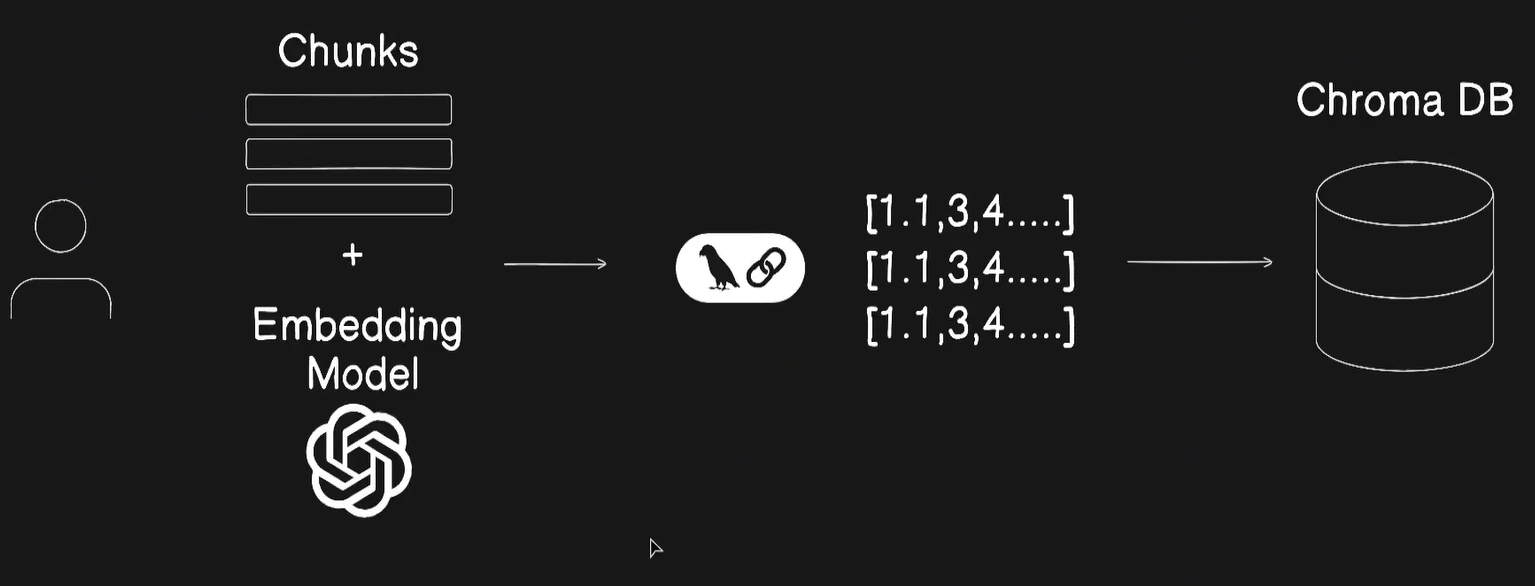

Langchain is converting our chunks into vectors. Now these vectors are now stored into Chroma DB automatically.

In [ ]:
# This is the backend logic like how embeddings are stored in the vector database.

vectors = []

for doc in chunks:
    vector = embedding_model.embed_documents([doc.page_content]) 
    vectors.append(vector)

#Doc is the first thing in our chunk, and we just need doc.page document

So it has run a loop over your chunks and yes it has used the embedding model that we have provided to create the embeddings for the 
page content and then it has just appended that vector store with those vector along with some metadata.

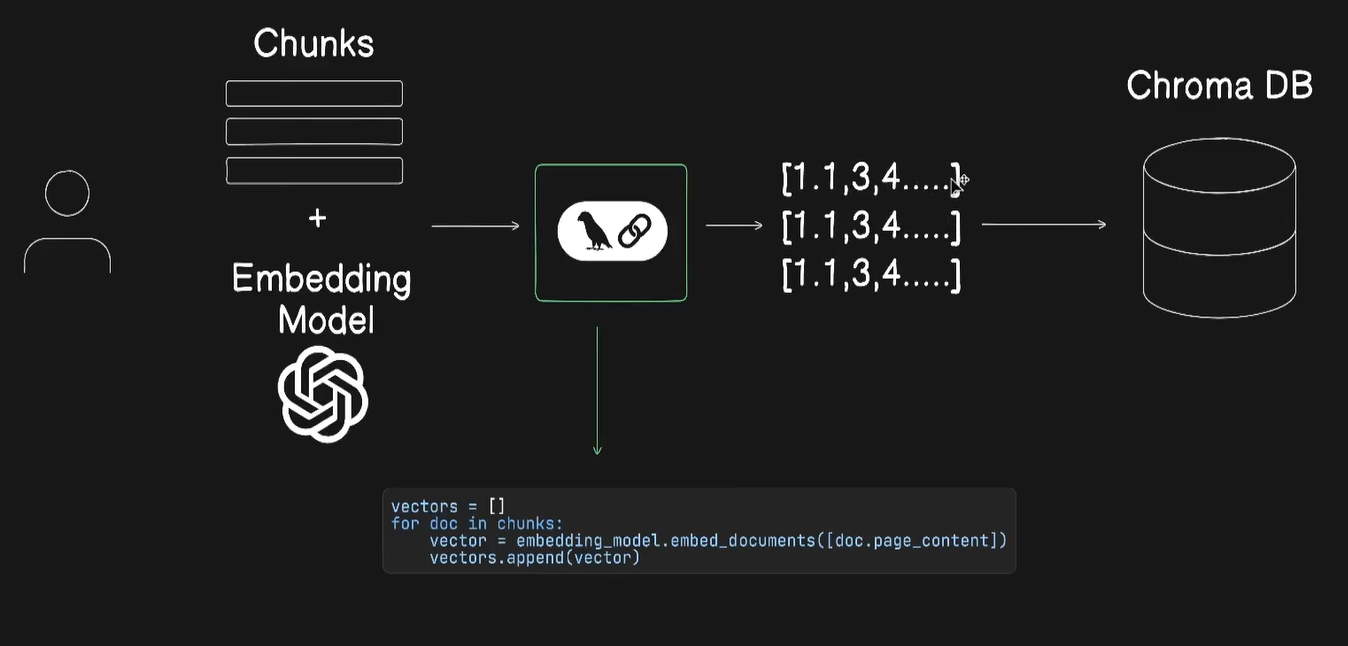

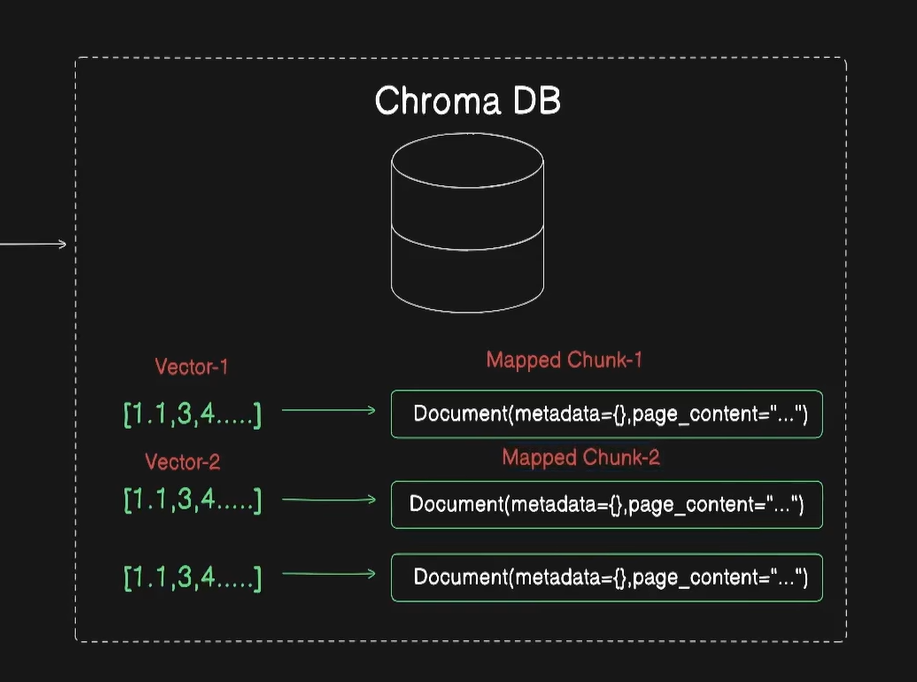

Now in chromadb it will store the vector and the mapped text, mapped chunk. 

#### **STEP 5: Semantic Search**

In [ ]:
vectorstore.similarity_search("Who is Rohit Sharma?", k=3) # We will get 3 chunks as output which are most similar to the query "Who is Rohit Sharma?"

[Document(metadata={'source': 'ABC', 'document_id': '123'}, page_content='Rohit Gurunath Sharma (born 30 April 1987) is an Indian international cricketer and the former captain of the India national cricket team in all formats of the game.[3] He is a right-handed top-order batter. He represents Mumbai in domestic cricket and Mumbai Indians in the Indian Premier League. Sharma was a member of the teams that won the 2007 T20 World Cup, the 2013 ICC Champions Trophy and was the winning captain of the 2024 T20 World Cup and the 2025 ICC Champions Trophy.'),
 Document(metadata={'source': 'ABC', 'document_id': '123'}, page_content="Sharma holds several batting records which include most runs in T20 Internationals, most sixes in international cricket,[a] most double centuries in ODI cricket (3), most centuries at Cricket World Cups (7) and joint most hundreds in Twenty20 Internationals (5).[5] He also holds the world record for the highest individual score (264) in a One Day International (OD

We got 3 relevant chunks based on the similarity search.

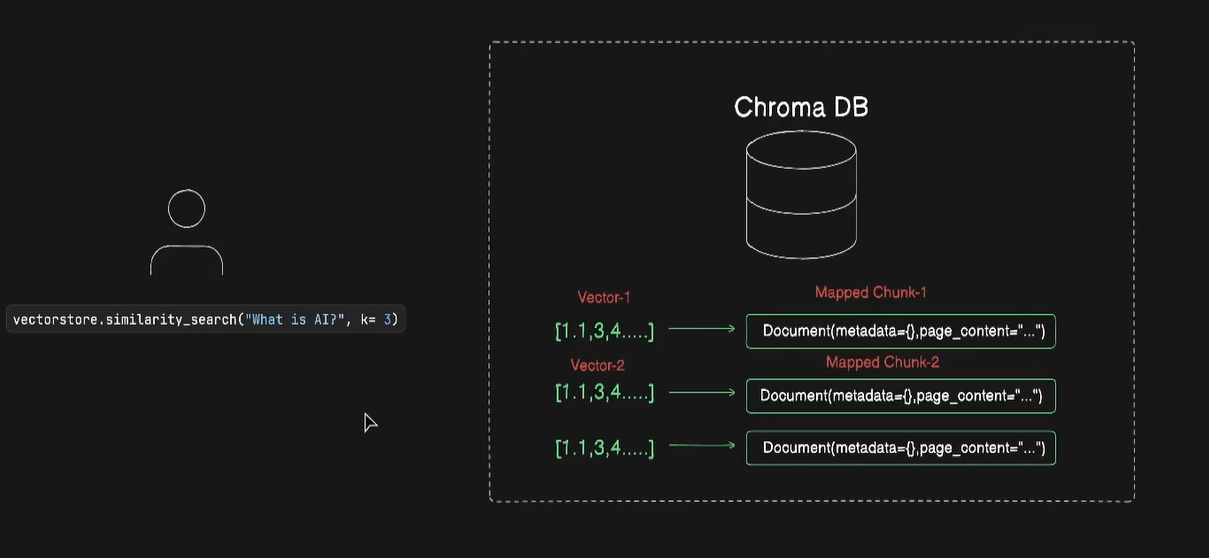

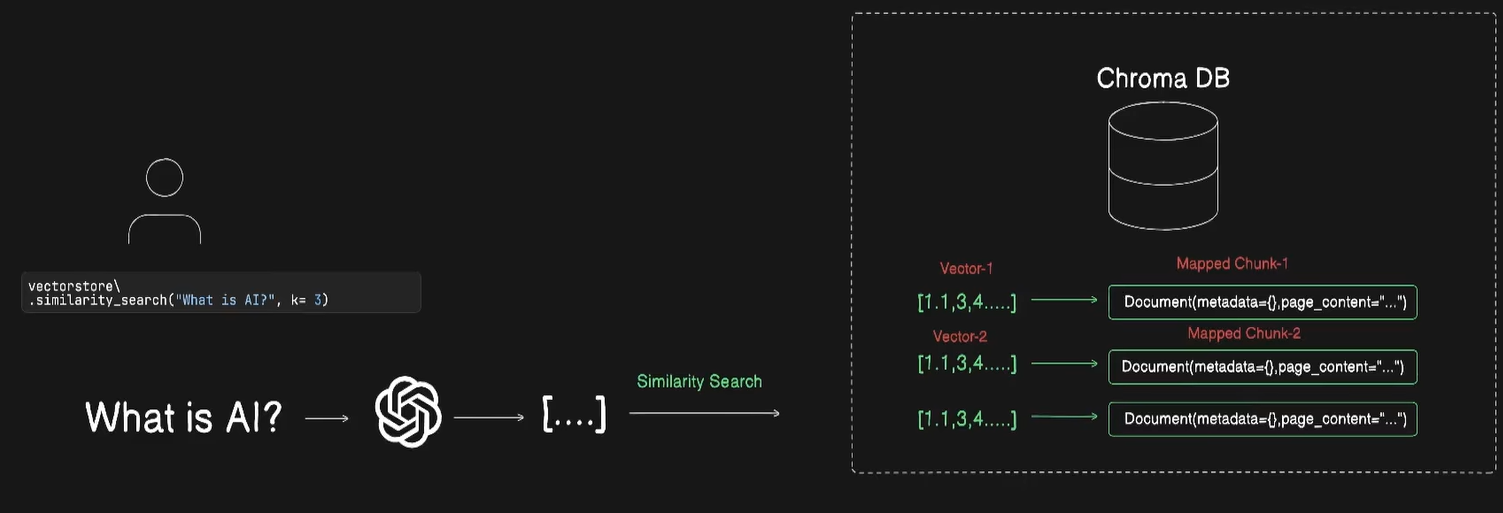

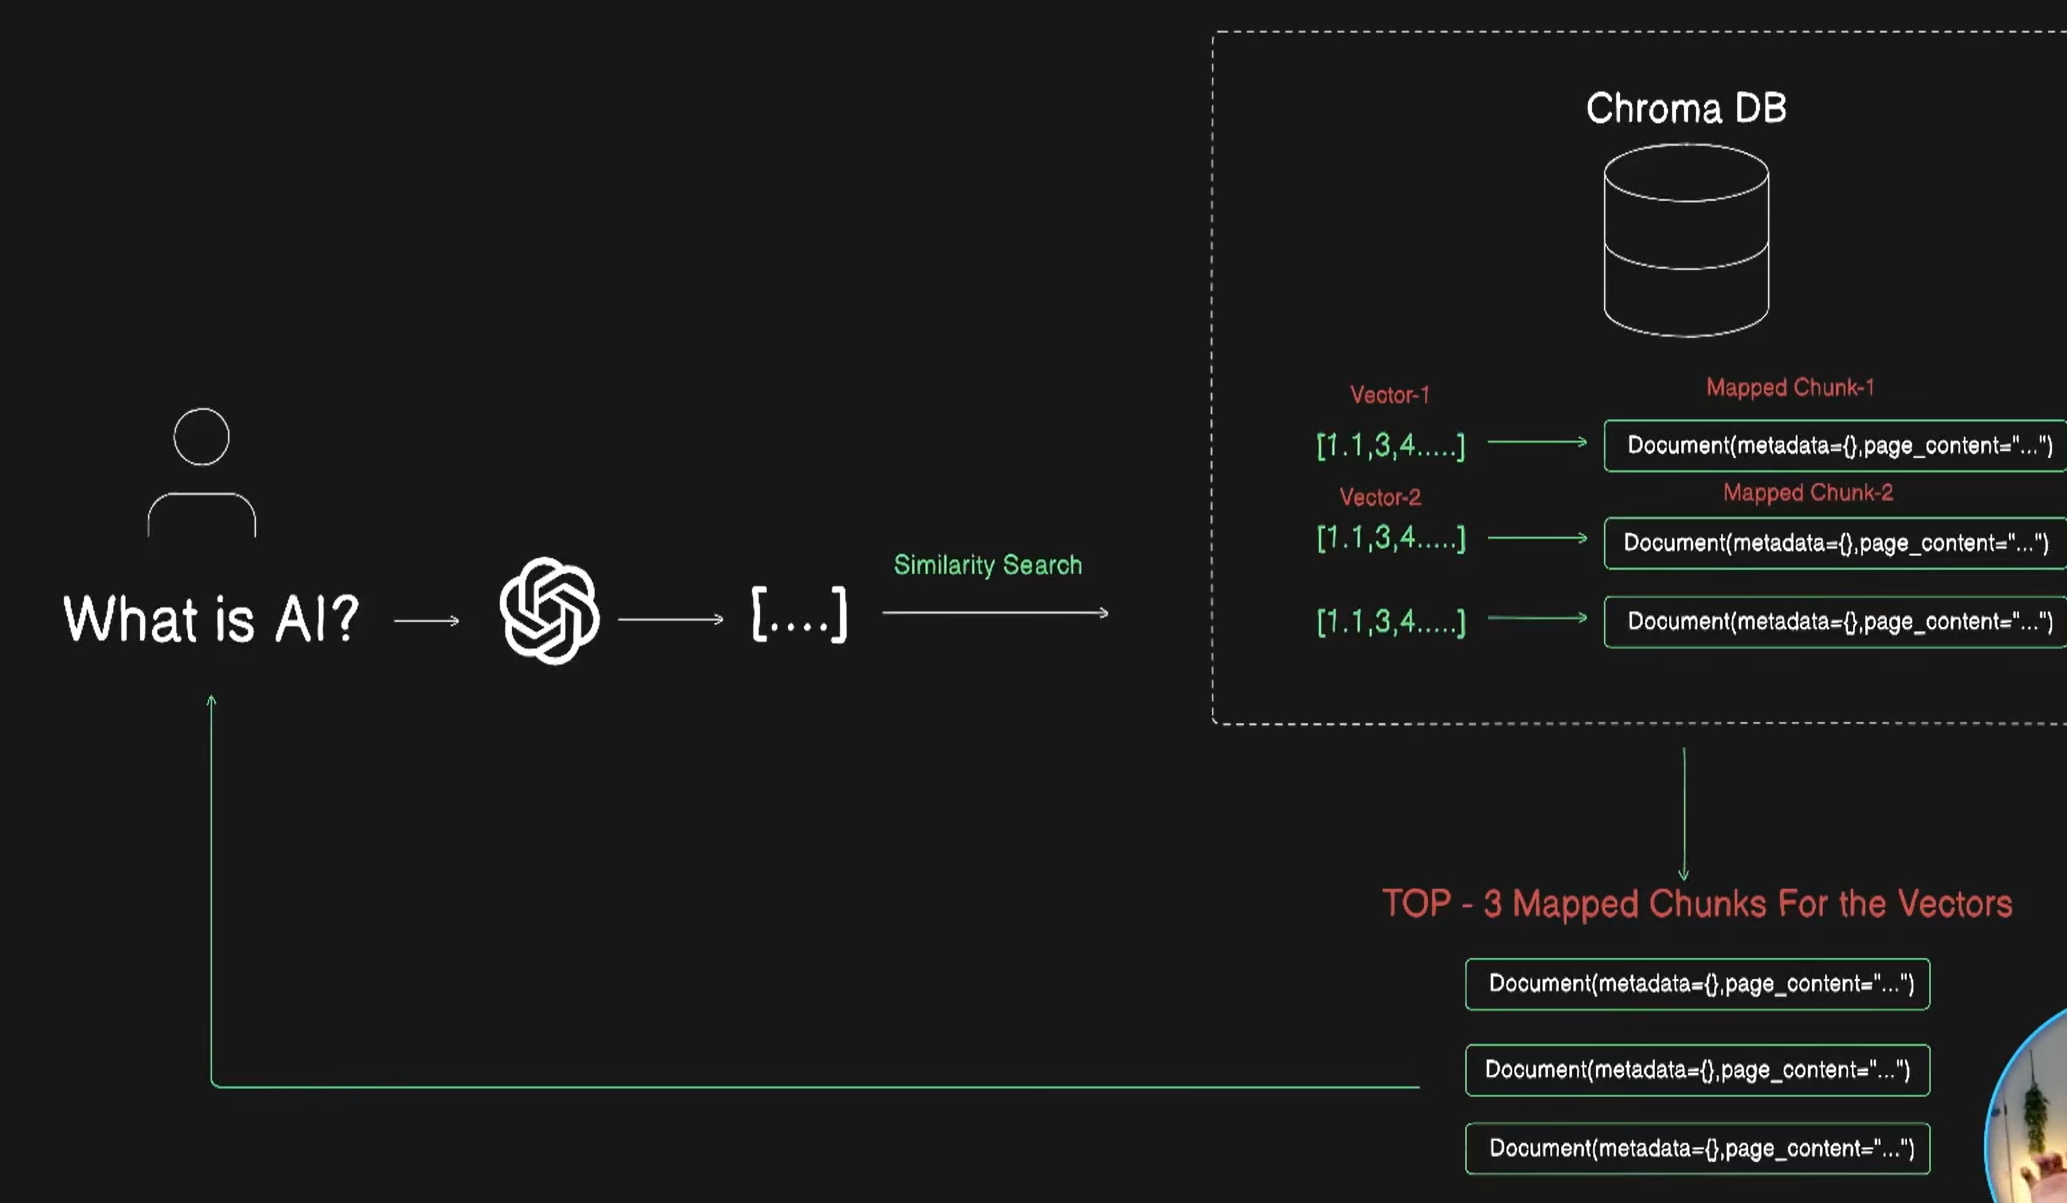

#### **Talk to LLM**

In [ ]:
llm.invoke("Who is Rohit Sharma?")

Now you will not use it like above

In [31]:
context = vectorstore.similarity_search("Who is Rohit Sharma?", k=3)

In [ ]:
response = llm.invoke("Who is Rohit Sharma? You can answer using the following context: {context}")
print(response.content)

'Rohit Gurunath Sharma (born 1 December 1987 in Nagpur, India) is an Indian cricketer. He is a right-handed opening batsman and occasional off-spinner who plays for India in international cricket and for the Mumbai Indians in the Indian Premier League (IPL), where he has been the captain and led the team to multiple titles. He is renowned for his white-ball prowess and is widely regarded as one of India’s greatest limited-overs batsmen. Notably, he holds the record for the highest individual ODI score (264) and has three ODI double centuries—the most by any batsman. He has also captained India in limited-overs cricket.'

This will give us the answer based on our context.

Did We upload any data to CHAT GPT, did we do anything with our sensitive data? No

We simply provided the context on the fly using our RAG Database.

This is the power of it.